# StochastiQ — Notebook 02: Markowitz Optimization

**Project:** StochastiQ — Multi-model portfolio optimization and derivatives strategy framework  
**Course:** MGT 6081 Derivative Securities, Georgia Institute of Technology  
**Author:** Anay Abhijit Joshi

---

## Objectives

Most portfolio optimization projects stop at the maximum Sharpe ratio portfolio. Different objective functions correspond to genuinely different views of risk, and they can produce materially different optimal weights. This notebook constructs and compares five portfolios:

1. **Maximum Sharpe** — the classical tangency portfolio.
2. **Minimum Variance** — the lowest-volatility portfolio on the efficient frontier.
3. **Maximum Sortino** — like Sharpe but penalizes only downside deviation, since investors do not actually mind upside volatility.
4. **Minimum CVaR (95%)** — minimizes the average loss in the worst 5% of trading days. This is the objective regulators and risk managers care about.
5. **Risk Parity** — each asset contributes equal risk to the portfolio. The philosophy underlying Bridgewater's All Weather strategy.

We then compute the full efficient frontier and plot all five portfolios on it.

## Mathematical Formulations

Let $\mathbf{w}$ be the vector of portfolio weights, $\boldsymbol{\mu}$ the vector of expected returns, $\Sigma$ the covariance matrix, and $r_f$ the risk-free rate. All optimizations use long-only ($w_i \geq 0$), fully-invested ($\mathbf{1}^\top \mathbf{w} = 1$) constraints.

$$
\begin{aligned}
\text{Max Sharpe:}    & \quad \max_{\mathbf{w}} \frac{\mathbf{w}^\top \boldsymbol{\mu} - r_f}{\sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}} \\
\text{Min Variance:}  & \quad \min_{\mathbf{w}} \mathbf{w}^\top \Sigma \mathbf{w} \\
\text{Max Sortino:}   & \quad \max_{\mathbf{w}} \frac{\mathbf{w}^\top \boldsymbol{\mu} - r_f}{\sigma_{\text{down}}(\mathbf{w})} \\
\text{Min CVaR}_\alpha:& \quad \min_{\mathbf{w}} \mathbb{E}[L \mid L \geq \text{VaR}_\alpha] \\
\text{Risk Parity:}   & \quad \min_{\mathbf{w}} \sum_i \left( \text{RC}_i(\mathbf{w}) - \frac{\sigma_p}{N} \right)^2
\end{aligned}
$$

where $\text{RC}_i = w_i \cdot (\Sigma \mathbf{w})_i / \sigma_p$ is asset $i$'s contribution to portfolio risk.

## 1. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loaders import load_dataset
from src.optimization.markowitz import (
    max_sharpe_portfolio,
    min_variance_portfolio,
    max_sortino_portfolio,
    min_cvar_portfolio,
    risk_parity_portfolio,
    efficient_frontier,
    build_all_portfolios,
    portfolios_summary_table,
    weights_comparison_table,
)

# Plot styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.figsize"] = (12, 5)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Configuration
RISK_FREE_RATE = 0.04   # 4% annualized
TRADING_DAYS = 252
CONFIDENCE = 0.95

print(f"Project root: {PROJECT_ROOT}")
print(f"Risk-free rate: {RISK_FREE_RATE:.1%}")
print(f"Trading days: {TRADING_DAYS}")

Project root: /Users/anayjoshi/Downloads/StochastiQ
Risk-free rate: 4.0%
Trading days: 252


## 2. Load Data

We load the cleaned log-return dataset produced by Notebook 01.

In [2]:
log_returns = load_dataset(PROCESSED_DIR / "log_returns.parquet")
prices = load_dataset(PROCESSED_DIR / "prices.parquet")

print(f"Log returns shape: {log_returns.shape}")
print(f"Date range: {log_returns.index.min().date()} to {log_returns.index.max().date()}")
print(f"Assets: {list(log_returns.columns)}")

log_returns.head()

Log returns shape: (1589, 7)
Date range: 2020-01-03 to 2026-04-30
Assets: ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM', 'SPY', 'GLD']


Ticker,AAPL,MSFT,JPM,JNJ,XOM,SPY,GLD
Date,,,,,,,
2020-01-03,-0.009770,-0.012530,-0.013284,-0.011645,-0.008072,-0.007601,0.013181
2020-01-06,0.007937,0.002582,-0.000795,-0.001248,0.007649,0.003808,0.010435
2020-01-07,-0.004714,-0.009160,-0.017147,0.006088,-0.008218,-0.002816,0.003927
2020-01-08,0.015958,0.015803,0.007771,-0.000137,-0.015195,0.005316,-0.007530
2020-01-09,0.021019,0.012415,0.003645,0.002962,0.007627,0.006758,-0.005668


## 3. Build All Five Portfolios

Each portfolio is computed by a separate optimization with its own objective. SLSQP is used as the solver because it handles linear equality constraints (sum-to-one) and bound constraints (long-only) natively.

In [3]:
portfolios = build_all_portfolios(
    log_returns,
    risk_free_rate=RISK_FREE_RATE,
    trading_days=TRADING_DAYS,
)

for key, portfolio in portfolios.items():
    print(f"  {portfolio.name:25s}  E[r]={portfolio.expected_return:6.2%}   sigma={portfolio.volatility:6.2%}   Sharpe={portfolio.sharpe_ratio:.3f}")

  Max Sharpe                 E[r]=17.49%   sigma=15.01%   Sharpe=0.898
  Min Variance               E[r]=14.26%   sigma=13.10%   Sharpe=0.783
  Max Sortino                E[r]=17.49%   sigma=15.03%   Sharpe=0.898
  Min CVaR (95%)             E[r]=14.12%   sigma=13.20%   Sharpe=0.767
  Risk Parity                E[r]=15.32%   sigma=16.49%   Sharpe=0.687


## 4. Side-by-Side Performance Comparison

In [4]:
summary = portfolios_summary_table(portfolios)
summary.style.format({
    "Annual Return":     "{:.2%}",
    "Annual Volatility": "{:.2%}",
    "Sharpe Ratio":      "{:.3f}",
    "Sortino Ratio":     "{:.3f}",
    "VaR 95%":           "{:.2%}",
    "CVaR 95%":          "{:.2%}",
}).background_gradient(subset=["Sharpe Ratio", "Sortino Ratio"], cmap="RdYlGn")\
  .background_gradient(subset=["VaR 95%", "CVaR 95%"], cmap="RdYlGn_r")

,Annual Return,Annual Volatility,Sharpe Ratio,Sortino Ratio,VaR 95%,CVaR 95%
Portfolio,,,,,,
Max Sharpe,17.49%,15.01%,0.898,1.265,1.39%,2.22%
Min Variance,14.26%,13.10%,0.783,1.106,1.23%,1.95%
Max Sortino,17.49%,15.03%,0.898,1.266,1.38%,2.22%
Min CVaR (95%),14.12%,13.20%,0.767,1.089,1.21%,1.94%
Risk Parity,15.32%,16.49%,0.687,0.959,1.42%,2.47%


**How to read this table:**
- The Max Sharpe portfolio achieves the highest Sharpe by construction. Other portfolios may underperform on Sharpe but excel on other dimensions.
- Min Variance has the lowest volatility but typically the lowest return as well.
- Max Sortino tends to overlap with Max Sharpe but with subtle differences when the asset return distribution is asymmetric.
- Min CVaR is the most defensive against tail losses, often shifting weight toward GLD given its near-zero correlation with equities.
- Risk Parity is the most diversified, ignoring expected returns entirely — a structural choice that pays off when expected-return forecasts are unreliable.

## 5. Weights Comparison

In [5]:
weights = weights_comparison_table(portfolios)
weights.style.format("{:.2%}")\
    .background_gradient(cmap="YlGn", axis=None)

,Max Sharpe,Min Variance,Max Sortino,Min CVaR (95%),Risk Parity
AAPL,20.04%,0.00%,21.81%,0.00%,11.23%
MSFT,0.00%,0.00%,0.00%,1.61%,11.84%
JPM,5.58%,0.00%,4.87%,0.00%,11.37%
JNJ,3.99%,30.84%,5.03%,37.02%,18.10%
XOM,8.31%,2.57%,7.22%,4.05%,10.79%
SPY,0.00%,20.71%,0.00%,10.21%,17.20%
GLD,62.08%,45.88%,61.07%,47.12%,19.47%


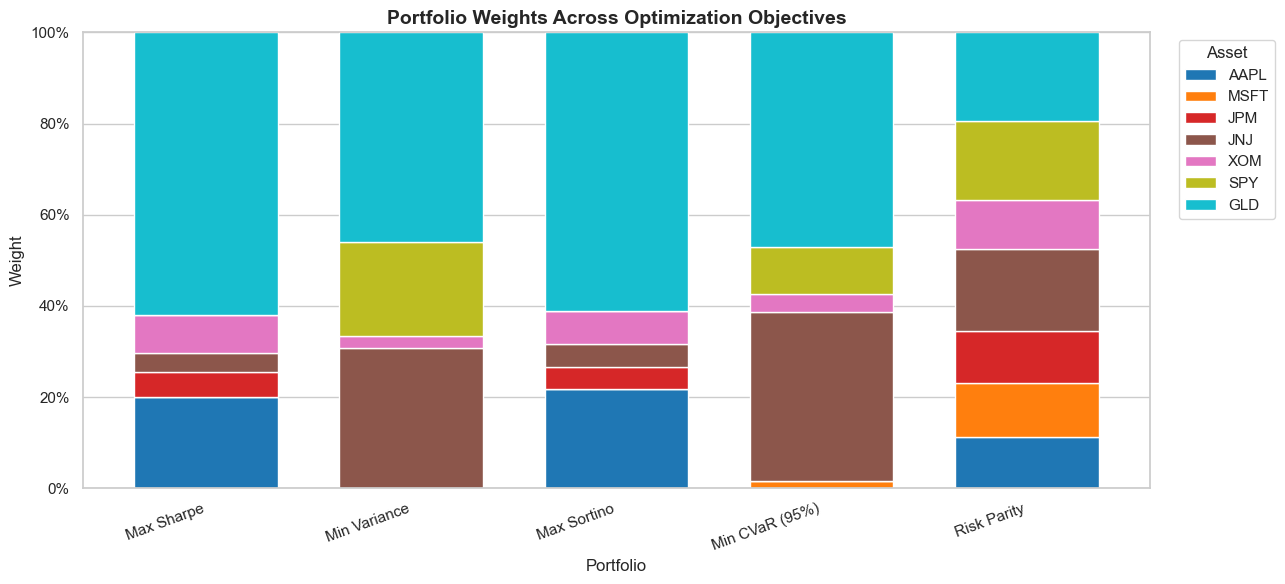

In [6]:
fig, ax = plt.subplots(figsize=(13, 6))
weights.T.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", width=0.7)
ax.set_title("Portfolio Weights Across Optimization Objectives", fontsize=14, fontweight="bold")
ax.set_ylabel("Weight")
ax.set_xlabel("Portfolio")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(title="Asset", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_weights_comparison.png", bbox_inches="tight")
plt.show()

## 6. The Efficient Frontier

The efficient frontier is the set of portfolios that achieve the minimum variance for each level of expected return. We compute it by solving a sequence of constrained minimum-variance problems sweeping through target returns.

In [7]:
frontier = efficient_frontier(log_returns, n_points=60, trading_days=TRADING_DAYS)
frontier["sharpe"] = (frontier["target_return"] - RISK_FREE_RATE) / frontier["volatility"]

frontier.head()

,target_return,volatility,sharpe
0,0.099625,0.194867,0.305976
1,0.101487,0.190161,0.323344
2,0.103350,0.185608,0.341311
3,0.105213,0.181164,0.359966
4,0.107076,0.176838,0.379307


### Headline Plot: Efficient Frontier with All Portfolios

This is the headline visualization for the report. It shows the full risk-return landscape of the universe.

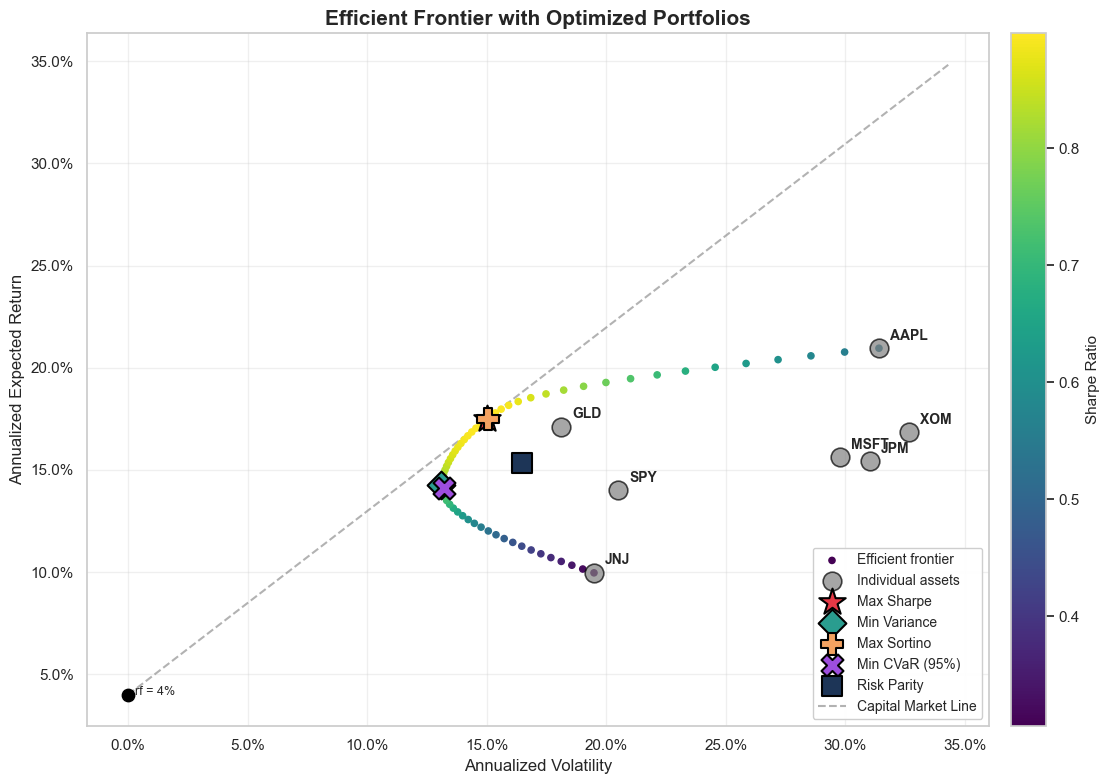

In [8]:
# Annualized stats for individual assets
asset_returns = log_returns.mean() * TRADING_DAYS
asset_vols = log_returns.std() * np.sqrt(TRADING_DAYS)

fig, ax = plt.subplots(figsize=(12, 8))

# 1. Efficient frontier curve, colored by Sharpe ratio
scatter = ax.scatter(
    frontier["volatility"],
    frontier["target_return"],
    c=frontier["sharpe"],
    cmap="viridis",
    s=20,
    label="Efficient frontier",
    zorder=3,
)
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Sharpe Ratio", fontsize=11)

# 2. Individual assets
ax.scatter(
    asset_vols, asset_returns,
    s=180, c="gray", alpha=0.7, edgecolors="black", linewidth=1.2,
    label="Individual assets", zorder=4,
)
for ticker in asset_returns.index:
    ax.annotate(
        ticker,
        (asset_vols[ticker], asset_returns[ticker]),
        xytext=(8, 6), textcoords="offset points",
        fontsize=10, fontweight="bold",
    )

# 3. Optimized portfolios
portfolio_colors = {
    "max_sharpe":   ("#e63946", "*", 400),
    "min_variance": ("#2a9d8f", "D", 200),
    "max_sortino":  ("#f4a261", "P", 250),
    "min_cvar":     ("#9d4edd", "X", 250),
    "risk_parity":  ("#1d3557", "s", 200),
}
for key, portfolio in portfolios.items():
    color, marker, size = portfolio_colors[key]
    ax.scatter(
        portfolio.volatility, portfolio.expected_return,
        s=size, c=color, marker=marker,
        edgecolors="black", linewidth=1.5,
        label=portfolio.name, zorder=5,
    )

# 4. Capital Market Line (from rf through Max Sharpe portfolio)
max_sharpe = portfolios["max_sharpe"]
x_cml = np.linspace(0, asset_vols.max() * 1.05, 100)
slope = (max_sharpe.expected_return - RISK_FREE_RATE) / max_sharpe.volatility
y_cml = RISK_FREE_RATE + slope * x_cml
ax.plot(x_cml, y_cml, "--", color="gray", alpha=0.6, label="Capital Market Line", zorder=2)
ax.scatter(0, RISK_FREE_RATE, s=80, c="black", marker="o", zorder=4)
ax.annotate(f"  rf = {RISK_FREE_RATE:.0%}", (0, RISK_FREE_RATE), fontsize=9)

ax.set_title("Efficient Frontier with Optimized Portfolios", fontsize=15, fontweight="bold")
ax.set_xlabel("Annualized Volatility", fontsize=12)
ax.set_ylabel("Annualized Expected Return", fontsize=12)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(loc="lower right", fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_efficient_frontier.png", bbox_inches="tight")
plt.show()

## 7. Backtest: Cumulative Returns of Each Portfolio

We apply each portfolio's weights to the historical return series to construct in-sample equity curves. This is in-sample (the weights were optimized on the same data), so this is purely descriptive. True out-of-sample validation comes in Notebook 06.

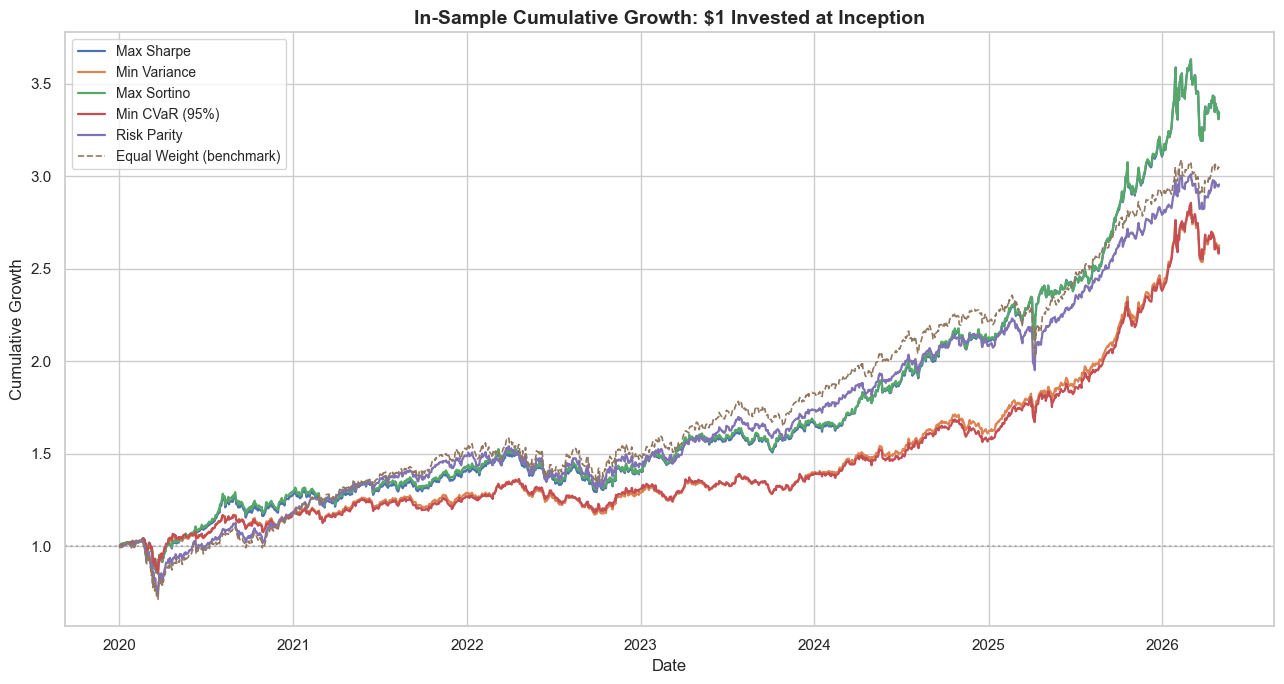


Final cumulative growth:
Max Sortino                   3.347x
Max Sharpe                    3.346x
Equal Weight (benchmark)      3.052x
Risk Parity                   2.957x
Min Variance                  2.627x
Min CVaR (95%)                2.612x
Name: 2026-04-30 00:00:00, dtype: str


In [9]:
# Convert log returns to simple returns for portfolio aggregation
simple_returns = np.exp(log_returns) - 1

equity_curves = pd.DataFrame(index=simple_returns.index)
for portfolio in portfolios.values():
    portfolio_simple_ret = simple_returns @ portfolio.weights
    equity_curves[portfolio.name] = (1 + portfolio_simple_ret).cumprod()

# Add an equal-weight benchmark for reference
n = simple_returns.shape[1]
equal_weight_ret = simple_returns @ (np.ones(n) / n)
equity_curves["Equal Weight (benchmark)"] = (1 + equal_weight_ret).cumprod()

fig, ax = plt.subplots(figsize=(13, 7))
for name in equity_curves.columns:
    style = "--" if "benchmark" in name else "-"
    width = 1.2 if "benchmark" in name else 1.6
    ax.plot(equity_curves.index, equity_curves[name], label=name, linestyle=style, linewidth=width)

ax.set_title("In-Sample Cumulative Growth: $1 Invested at Inception", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Growth")
ax.legend(loc="upper left", fontsize=10)
ax.axhline(1.0, color="gray", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_equity_curves.png", bbox_inches="tight")
plt.show()

print("\nFinal cumulative growth:")
print(equity_curves.iloc[-1].sort_values(ascending=False).apply(lambda x: f"  {x:.3f}x"))

## 8. Maximum Drawdown Analysis

Drawdown is the peak-to-trough decline at each point in time. Maximum drawdown is the worst such decline ever observed. Markowitz optimization minimizes variance, but drawdown is what investors actually experience emotionally — and what causes redemptions in real portfolios.

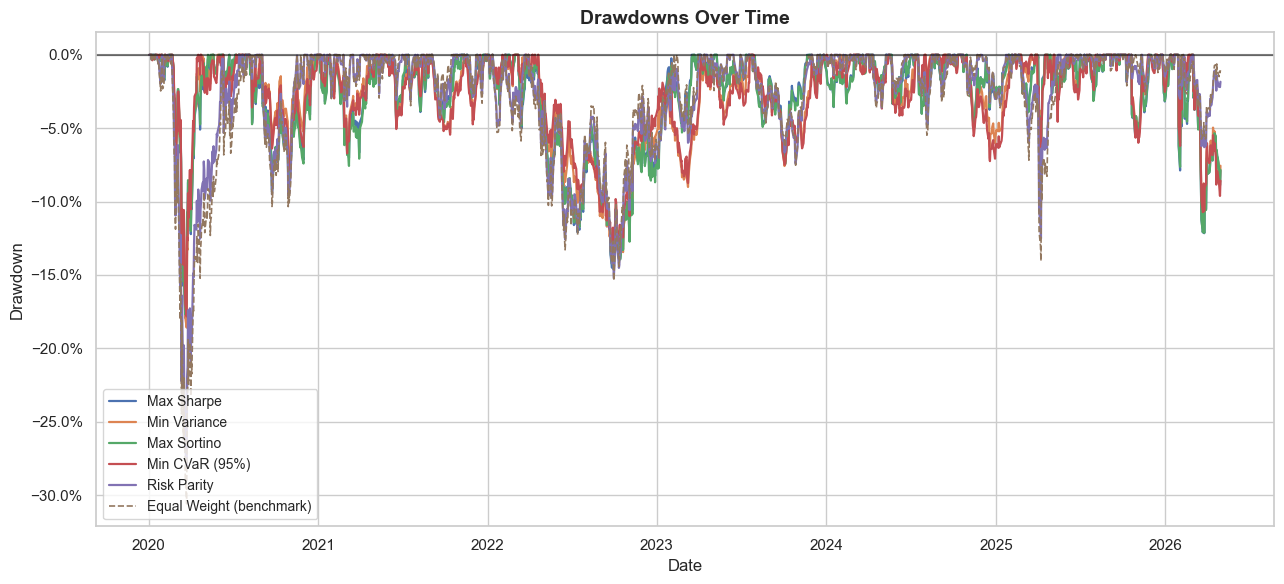


Maximum drawdown by portfolio:
  Equal Weight (benchmark)        -30.59%
  Risk Parity                     -28.21%
  Min Variance                    -18.59%
  Max Sharpe                      -17.93%
  Min CVaR (95%)                  -17.83%
  Max Sortino                     -17.68%


In [10]:
def compute_drawdown(equity_curve: pd.Series) -> pd.Series:
    running_max = equity_curve.cummax()
    return (equity_curve - running_max) / running_max

drawdowns = equity_curves.apply(compute_drawdown)

fig, ax = plt.subplots(figsize=(13, 6))
for name in drawdowns.columns:
    style = "--" if "benchmark" in name else "-"
    width = 1.2 if "benchmark" in name else 1.6
    ax.plot(drawdowns.index, drawdowns[name], label=name, linestyle=style, linewidth=width)

ax.set_title("Drawdowns Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(loc="lower left", fontsize=10)
ax.axhline(0, color="black", linestyle="-", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_drawdowns.png", bbox_inches="tight")
plt.show()

print("\nMaximum drawdown by portfolio:")
max_dd = drawdowns.min().sort_values()
for name, dd in max_dd.items():
    print(f"  {name:30s}  {dd:.2%}")

## 9. Save Outputs

In [11]:
# Save weights and summary tables to processed data folder
weights.to_parquet(PROCESSED_DIR / "portfolio_weights.parquet")
summary.to_parquet(PROCESSED_DIR / "portfolio_summary.parquet")
frontier.to_parquet(PROCESSED_DIR / "efficient_frontier.parquet")
equity_curves.to_parquet(PROCESSED_DIR / "equity_curves.parquet")

print("Saved outputs:")
for fname in ["portfolio_weights", "portfolio_summary", "efficient_frontier", "equity_curves"]:
    fpath = PROCESSED_DIR / f"{fname}.parquet"
    print(f"  {fpath.relative_to(PROJECT_ROOT)}  ({fpath.stat().st_size / 1024:.1f} KB)")

Saved outputs:
  data/processed/portfolio_weights.parquet  (4.7 KB)
  data/processed/portfolio_summary.parquet  (5.2 KB)
  data/processed/efficient_frontier.parquet  (4.3 KB)
  data/processed/equity_curves.parquet  (104.0 KB)


## 10. Summary

We constructed five portfolios under different objective functions and benchmarked them against an equal-weight portfolio.

**Key takeaways:**

- Different objective functions produce materially different optimal weights. The Max Sharpe portfolio concentrates in the highest risk-adjusted assets, while Risk Parity spreads weight more evenly — particularly toward GLD.
- Min CVaR is the most defensive against tail losses, since it explicitly minimizes the average loss in the worst 5% of days.
- All portfolios beat the equal-weight benchmark on Sharpe, but with different drawdown profiles.
- These weights are in-sample optimized; out-of-sample performance will be tested in Notebook 06.

**Next:** Notebook 03 — Calibrate the four stochastic models (GBM, Merton, CEV, Heston) to each asset's historical returns.